In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

In [5]:
# Load the new polynomial dataset
df = pd.read_csv('polynomial.csv')
print("📊 Dataset Sample:")
print(df.head())

# Using consistent variable names (Uppercase X for features)
X = df[['hours']].values
y = df['scores'].values

📊 Dataset Sample:
   hours  scores
0    1.0      12
1    1.2      14
2    1.5      16
3    2.0      18
4    2.2      20


In [6]:
# Transform features to Polynomial (Degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_poly, y)

print("✅ Polynomial model trained successfully.")

✅ Polynomial model trained successfully.


c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


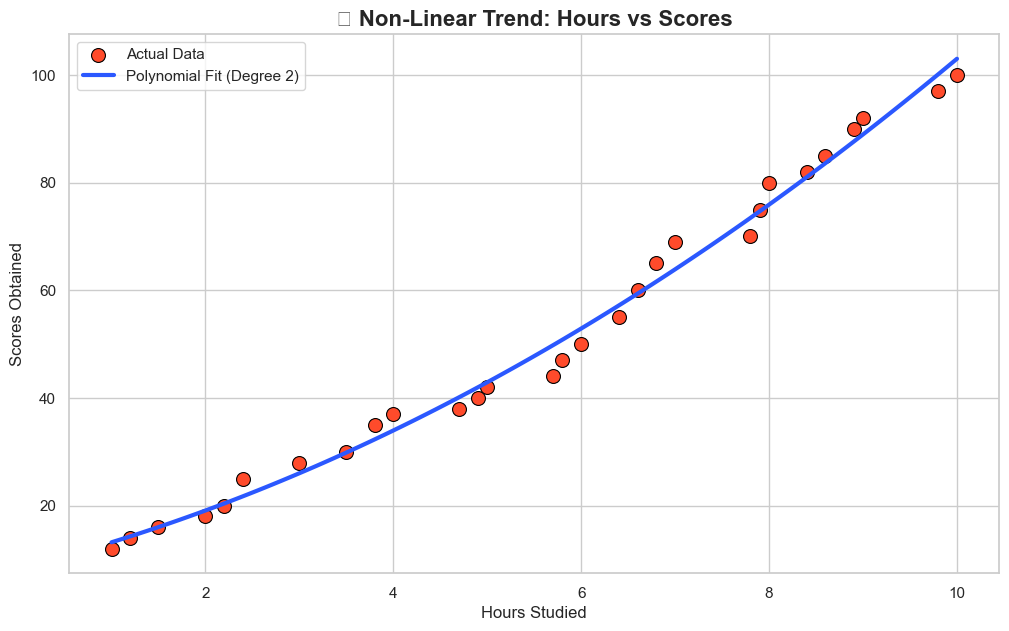

In [7]:
# Visualize the data and the polynomial fit
plt.figure(figsize=(12, 7))

# Actual data points
sns.scatterplot(x=df['hours'], y=df['scores'], color='#ff4b2b', s=100, label='Actual Data', edgecolor='black')

# Generate points for the smooth curve
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_poly_pred = model.predict(X_range_poly)

plt.plot(X_range, y_poly_pred, color='#2b58ff', linewidth=3, label='Polynomial Fit (Degree 2)')

plt.title('🎓 Non-Linear Trend: Hours vs Scores', fontsize=16, fontweight='bold')
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Scores Obtained', fontsize=12)
plt.legend()
plt.show()

In [8]:
# Model Evaluation
y_pred = model.predict(X_poly)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Overall R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

Overall R² Score: 0.9901
Mean Squared Error: 7.16


In [9]:
# Custom Prediction Function with User Input
def predict_score(hours):
    hours_poly = poly.transform([[hours]])
    prediction = model.predict(hours_poly)[0]
    print(f"\n🔮 Prediction for {hours} hours of study:")
    print(f"Estimated Score: {prediction:.2f}")

# Input from User
try:
    user_hours = float(input("Enter hours studied: "))
    predict_score(user_hours)
except ValueError:
    print("❌ Invalid input! Please enter a numeric value for hours.")



🔮 Prediction for 8.0 hours of study:
Estimated Score: 75.92
